In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

# Pre-processing

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


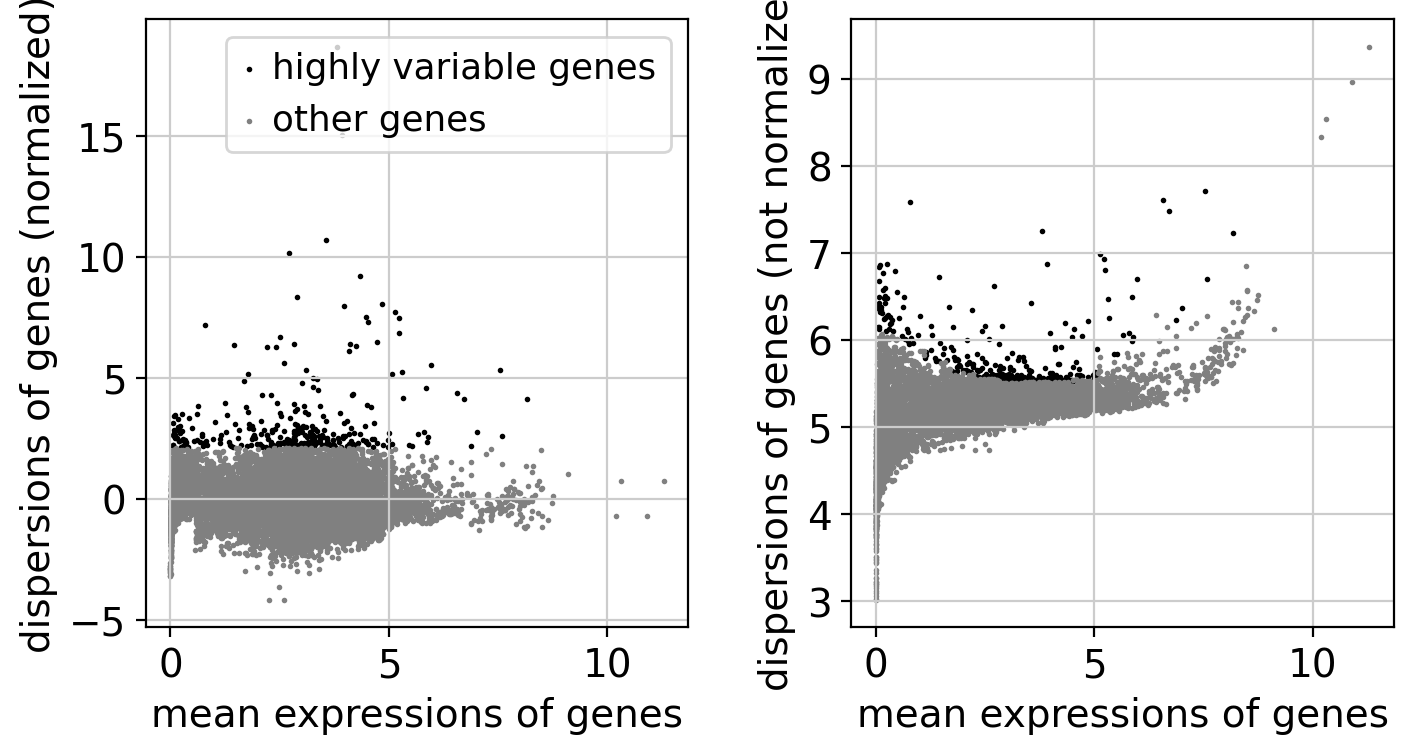

there are 300 hvgs


In [2]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', n_top_genes=300)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

In [3]:
# > lymph node
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
avis2 = avis.copy()
# add necessary attributes from metadata
avis2.obs['sample_id'] = 'sample'
avis2.obsm['spatial'] = avis2.obs[['imagerow','imagecol']].values

In [4]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()
avis1 = avis1[avis1.X.sum(1).A1 > 0].copy()
avis2 = avis2[avis2.X.sum(1) > 0].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('../celcomen/data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('../celcomen/data/preproc_lymphnode.h5ad')

# Run inference module to learn intra- and inter-cellular gene-gene forces

In [5]:
# load model
from celcomen.models.celcomen import celcomen

from celcomen.training_plan.train import train

from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [7]:
from torch_geometric.loader import DataLoader
import scanpy as sc
import torch
import torch_geometric
#from torch_cluster.knn import knn_graph
from sklearn.neighbors import kneighbors_graph
import numpy as np

from scipy.spatial.distance import pdist, squareform

def get_dataset_loaders(h5ad_path: str, sample_id_name: str, n_neighbors: int, device: str, verbose: bool):
    """
    Prepares and returns PyTorch Geometric DataLoader from a single-cell spatial transcriptomics dataset.

    The function reads a single-cell AnnData object from an H5AD file, normalises the data, and generates 
    graph data where nodes correspond to cells, and edges are created based on spatial proximity using 
    a k-nearest neighbours graph. The data is then loaded into a PyTorch Geometric `DataLoader`.

    Parameters
    ----------
    h5ad_path : str
        Path to the H5AD file containing the raw counts of the single-cell spatial transcriptomics data.
    sample_id_name : str
        Name of the sample ID column in `adata.obs` to separate the dataset into different samples.
    n_neighbors : int
        Number of neighbours to use for constructing the k-nearest neighbours graph for spatial information.
    verbose : bool
        If True, prints detailed information about the DataLoader during the loading process.

    Returns
    -------
    DataLoader
        A PyTorch Geometric DataLoader containing the processed graph data, with each graph representing
        a sample of cells in the dataset.

    Notes
    -----
    - The spatial positions of the cells are used to create a k-nearest neighbours graph, with edges
      connecting cells that are spatially close to each other.
    - The input features for the graph (`x`) are normalised before constructing the graph.
    - `adata.obsm["spatial"]` is used to extract the spatial coordinates of the cells.
    - The graph data is validated using PyTorch Geometric's built-in validation method.

    Examples
    --------
    >>> loader = get_dataset_loaders('data.h5ad', 'sample_id', n_neighbors=6, verbose=True)
    Step 1
    =====
    Number of graphs in the current batch: 1
    Data(x=[100, 33500], edge_index=[2, 500], pos=[100, 2], y=[1])

    Raises
    ------
    ValueError
        If there are issues with the input data during validation, e.g., if the graph is not well-formed.
    """

    adata = sc.read_h5ad(h5ad_path) 

    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)

    adata_list = [  adata[adata.obs[sample_id_name]==i] for i in set(adata.obs[sample_id_name])  ]

    data_list = []
    n_neighbors = 6

    for adata in adata_list:
        pos = torch.from_numpy(adata.obsm["spatial"])
        x = torch.from_numpy(adata.X.todense())    
        # normalize x 
        norm_factor = torch.pow(x,2).sum(1).reshape(-1,1)
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])   # here we will store GT value
        # compute the edges as two cell widths apart so 30µm
        edge_index = torch.from_numpy(np.array(np.where(kneighbors_graph(adata.obsm['spatial'], n_neighbors=6, include_self=False).toarray() == 1))).to(device)
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)    # performs basic checks on the graph
        data_list.append(data)

    loader = DataLoader( data_list, batch_size=1, shuffle=True)

    if verbose:
        for step, data in enumerate(loader):
            print(f'Step {step+1}')
            print("=====")
            print(f'Number of graphs in the current batch: {data.num_graphs}')
            print(data)
            print()

    return loader

In [8]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_lymphnode.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 300], edge_index=[2, 18600], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 300], edge_index=[2, 14592], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 300], edge_index=[2, 18618], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 300], edge_index=[2, 12912], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 300], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



### Select the hyperparameters of the model.
zmft_scalar should be the highest value in the range (0,1) such that the loss can be stably minimized. 
n_neighbors should be selected based on what disentanglement we want to achieve in the data. n_neighbors=6 targets disentanglement between intracellular and intercellular forces of short range.

In [50]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-6
seed = 0
epochs = 20

100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  5.64it/s]


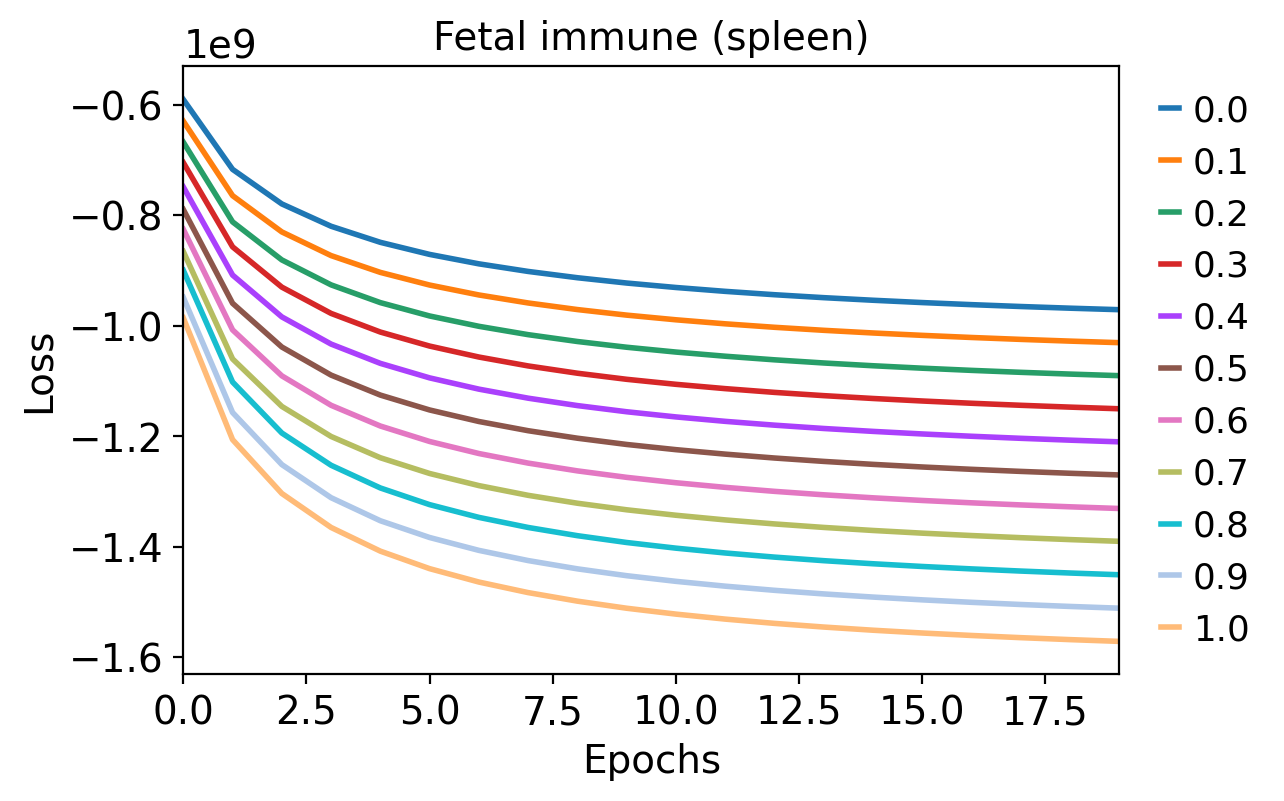

In [51]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
for zmft_scalar in np.arange(0, 1+.1, .1):
    zmft_scalar = round(zmft_scalar, 1)
    # instantiate models on cpu
    model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model1.set_g2g(torch.from_numpy(input_g2g))
    model1.set_g2g_intra(torch.from_numpy(input_g2g))
    model1.to('cpu')
    # train the models
    losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    ax.plot(losses1, lw=2, label=zmft_scalar)
ax.set_xlim(0, epochs-1)
vmin, vmax = ax.get_ylim()
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')
ax.legend(bbox_to_anchor=(1.01, .5), bbox_transform=ax.transAxes, frameon=False, loc='center left')

In [56]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-10
seed = 0
epochs = 20

100%|███████████████████████████████████████████| 20/20 [00:02<00:00,  8.95it/s]


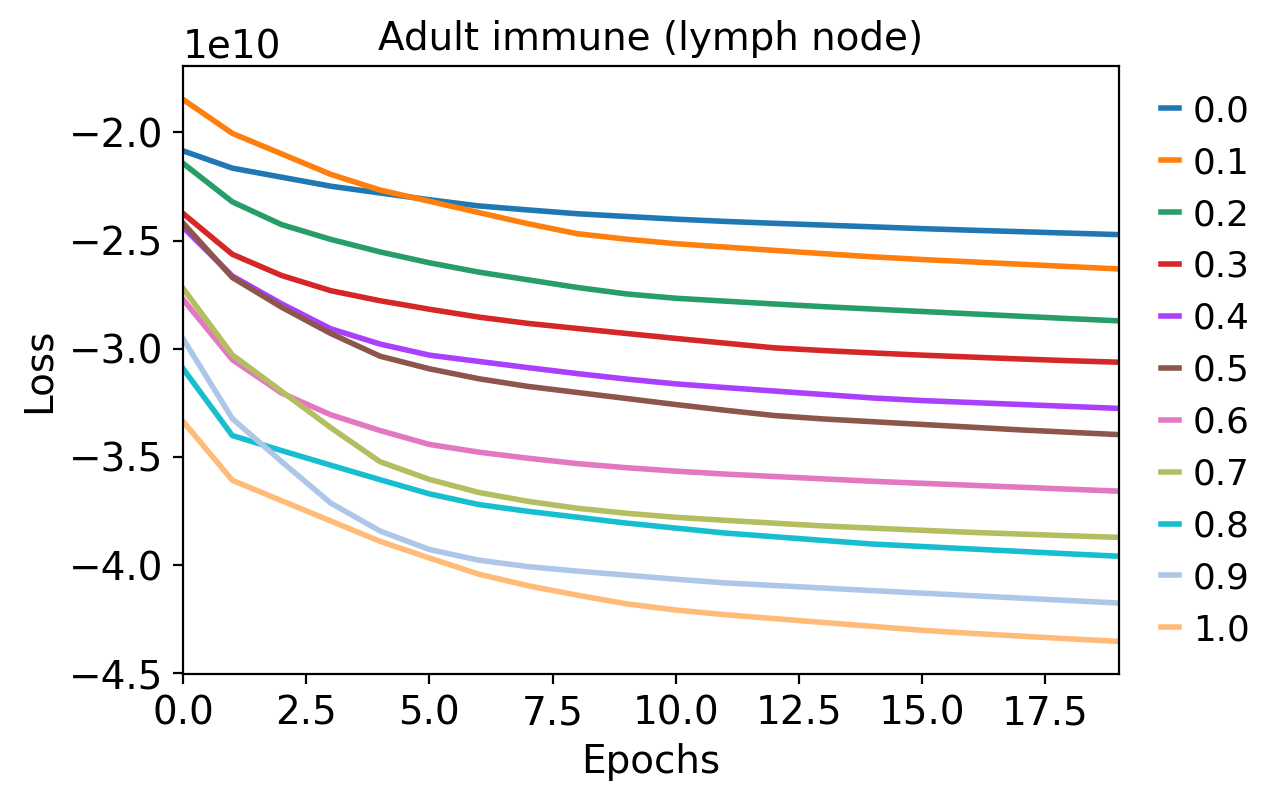

In [57]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
for zmft_scalar in np.arange(0, 1+.1, .1):
    zmft_scalar = round(zmft_scalar, 1)
    # instantiate models on cpu
    model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model2.set_g2g(torch.from_numpy(input_g2g))
    model2.set_g2g_intra(torch.from_numpy(input_g2g))
    model2.to('cpu')
    # train the models
    losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    ax.plot(losses2, lw=2, label=zmft_scalar)
ax.set_xlim(0, epochs-1)
vmin, vmax = ax.get_ylim()
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')
ax.legend(bbox_to_anchor=(1.01, .5), bbox_transform=ax.transAxes, frameon=False, loc='center left')

In [ ]:
print()